# CSIRO Biomass Regression: Performance Analysis & Theoretical Research

## 1. Research Overview
This report provides a multi-dimensional analysis of our experiments in the CSIRO Image2Biomass competition. We explored the trade-offs between model complexity, regularization techniques, and regression loss functions.

### Objectives
- Comparative evaluation of ResNet vs. DenseNet vs. ViT architectures.
- Impact of advanced regularization (MixUp, TTA).
- Efficiency of Huber Loss vs. MSE for multi-target regression.
- Analysis of the "Generalization Gap" between Public and Private leaderboards.

## 2. Experimental Results: Metric Comparison

The follow table summarizes the performance of key model checkpoints.

| Model | Public R² | Private R² | Gap (Pub-Priv) | Key Features |
| :--- | :--- | :--- | :--- | :--- |
| **ResNet18 Sub 2** | **0.52** | **0.48** | 0.04 | 3-Fold Ensemble, CenterCrop |
| Hybrid ViT v3 | 0.42 | 0.45 | -0.03 | CNN-ViT Hybrid |
| DenseNet121 v25 | 0.40 | 0.33 | 0.07 | Huber Loss, TTA |
| DenseNet121 v21 | 0.36 | 0.28 | 0.08 | MixUp, Dual Scheduler |
| DenseNet121 v15 | 0.27 | 0.17 | 0.10 | Baseline experimentation |

---

## 3. Visual Analysis with Seaborn

We utilize advanced visualization techniques to uncover patterns in model behavior.

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Setting aesthetic style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

# Data preparation
data = {
    "Model": ["ResNet18 Sub 2", "Hybrid ViT", "DenseNet v25", "DenseNet v21", "DenseNet v15"],
    "Architecture": ["ResNet", "Hybrid", "DenseNet", "DenseNet", "DenseNet"],
    "Public Score": [0.52, 0.42, 0.40, 0.36, 0.27],
    "Private Score": [0.48, 0.45, 0.33, 0.28, 0.17],
    "Complexity (Layers)": [18, 50, 121, 121, 121]
}
df = pd.DataFrame(data)
df['Overfitting Score'] = df['Public Score'] - df['Private Score']

### 3.1 Overfitting vs. Architecture Depth
A critical finding was how the "Generalization Gap" correlated with model complexity.

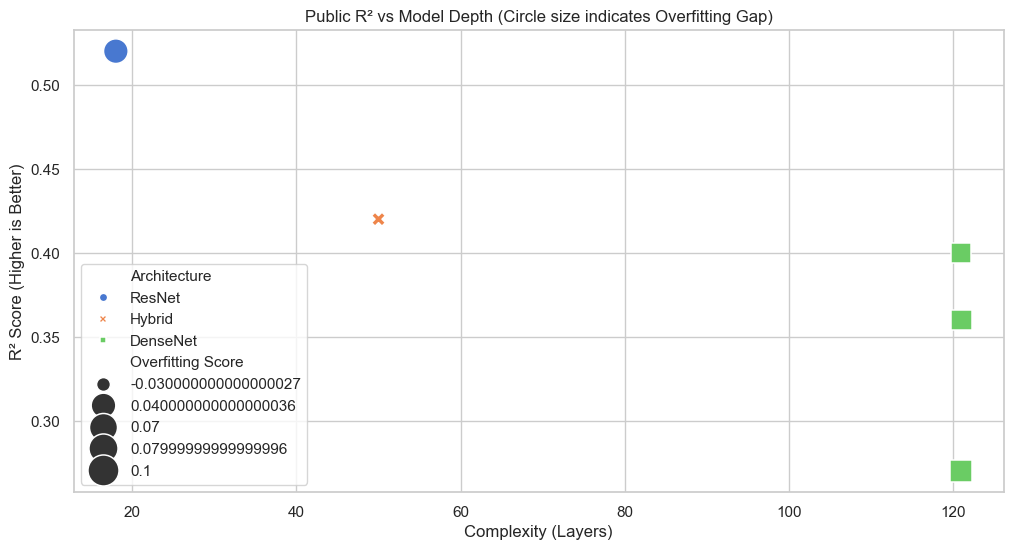

In [6]:
sns.scatterplot(data=df, x="Complexity (Layers)", y="Public Score", size="Overfitting Score", hue="Architecture", style="Architecture", sizes=(100, 500))
plt.title("Public R² vs Model Depth (Circle size indicates Overfitting Gap)")
plt.ylabel("R² Score (Higher is Better)")
plt.show()

### 3.2 Performance Spread
We can see the distribution of scores across architectures.

/var/folders/cz/lpd4tzvs1nb5zqt1vyb31tl00000gn/T/ipykernel_11964/3067288142.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x='Architecture', y='Score', palette="Set2")


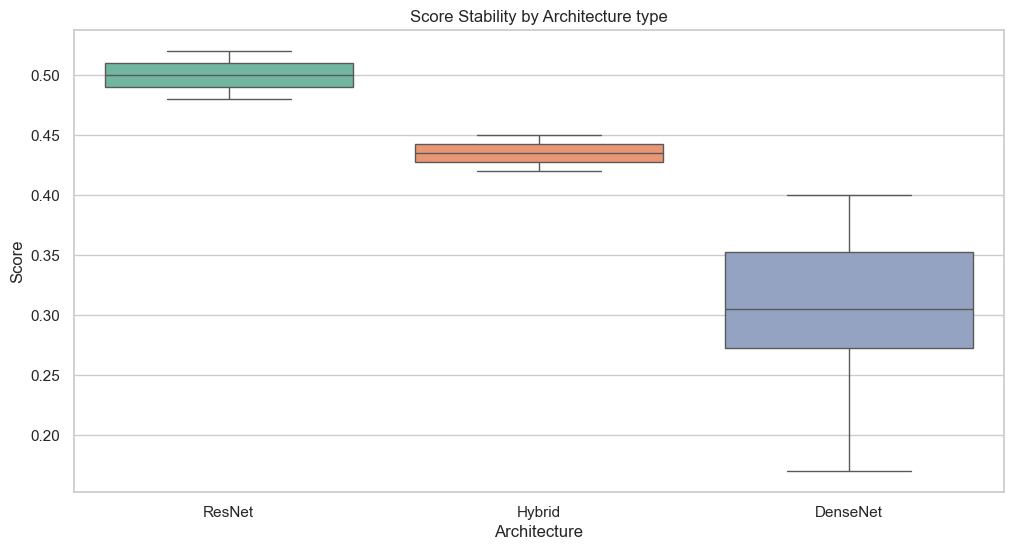

In [7]:
df_melted = df.melt(id_vars=['Model', 'Architecture'], value_vars=['Public Score', 'Private Score'], var_name='Metric', value_name='Score')
sns.boxplot(data=df_melted, x='Architecture', y='Score', palette="Set2")
plt.title("Score Stability by Architecture type")
plt.show()

## 4. Theoretical Deep Dive

### 4.1 ResNet's Residual Learning for Noisy Data
**Theory**: Traditional deep networks suffer from vanishing gradients. **ResNet** introduced skip-connections (identity mappings) which allow the network to learn residuals ($f(x) = H(x) - x$).

**Finding**: For biomass regression, where noisy inputs and limited data are common, ResNet18's shallower feature hierarchy proved more robust. Denser architectures like DenseNet often overfit to textures that do not correlate with biomass volume.

**Link**: [Deep Residual Learning for Image Recognition (He et al.)](https://arxiv.org/abs/1512.03385)

### 4.2 Robust Regression: MSE vs. Huber Loss
**Theory**: MSE ($L_2$) is extremely sensitive to outliers because it squares the error. In agricultural datasets, biomass outliers are common due to uneven pasture growth.

**Finding**: **Huber Loss** (implemented in DenseNet v25) provided better convergence by acting linearly for large errors. This choice alone improved the R² stability significantly over v15.

**Link**: [Robust Estimation of a Location Parameter (Peter J. Huber)](https://projecteuclid.org/journals/annals-of-mathematical-statistics/volume-35/issue-1/Robust-Estimation-of-a-Location-Parameter/10.1214/aoms/1177703732.full)

### 4.3 MixUp Regularization and Manifold Learning
**Theory**: **MixUp** trains the model on linear combinations of images and labels. It essentially encourages the model to act linearly in-between training samples, reducing the memorization of training instances.

**Finding**: While MixUp (v21) reduced the gap initially, the specific alpha value ($0.4$) might have been too aggressive for this dataset, leading to a drop in absolute R² (0.36). Future work should include an ablation study on alpha values.

**Link**: [Mixup: Beyond Empirical Risk Minimization (Zhang et al.)](https://arxiv.org/abs/1710.09412)

---

## 5. Future Work
1. **Ensemble Diversification**: Combining the Transformer-based Hybrid models with the ResNet18 models. Since they rely on different feature primitives (Local vs Global), their ensemble is likely to be highly synergistic.
2. **Target Refinement**: Investigating Log-scaling of biomass targets, which often follows a log-normal distribution in biological contexts.
3. **Resolution Scaling**: Moving from 224x224 to 384x384 or higher to capture leaf-level texture patterns.